# Задание
• На основе датасета, который был использован вами для промежуточной аттестации (или другого):

• Выберите вещественную переменную в качестве таргета и несколько объясняющих переменных

• Постройте точечные диаграммы (scatterplots) для таргета и каждой фичи, опишите форму взаимосвязи между переменными

• Разделите датасет на обучающую и тестовую выборки

• Сделайте масштабирование объясняющих переменных

• Обучите модели Lasso и Ridge на разных наборах переменных и для разных спецификаций модели на обучающейвыборке

• Сделайте предсказания целевой переменной для тестовой выборки

• Рассчитайте метрики качества

• Выберите спецификацию модели с наилучшим качеством

• Сделайте выводы относительно полученной модели и ее качества

• Разместите блокнот в GitHub и прикрепите ссылку на блокнот в удаленном репозитории


# Подготовка


## Данные

Данные были сформированы из MSSQL Server базы компании и выгружены в Excel для дальнейшей обработки. В качестве источника представлены два набора данных:
* empl_1.xlsx - список сотрудников по месячно, (date - месяц и год, qnt - количество сотрудников, имеющих доступ к компьютерам, qnt_total - общее количество сотрудников)
* data_1.xlsx - список покупок (я удалил конкретные наименования товаров, оставил только категории( date - месяц и год, category - категория, qnt - количество)

## Описание задачи

В качестве задачи я решил взять предсказание затрат на Мониторы в следующем месяце (взял только одну категорию товаров, для примера).


## Импорт пакетов

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme()

## Загрузка данных

In [3]:
employeeRaw = (pd
                .read_excel("empl_1.xlsx")
                .sort_values('date')
)
dataRaw = (pd
           .read_excel("data_1.xlsx")
           .sort_values('date')
)
print("Сотрудники: ", employeeRaw.shape)
print("Покупки: ", dataRaw.shape)

print(dataRaw.groupby("category").nunique().index.tolist())

Сотрудники:  (129, 3)
Покупки:  (4728, 4)
['Батарейка', 'Блок питания', 'Веб-камера', 'Видеокарта', 'Жесткий диск', 'Запчасти для компьютера', 'Запчасти для принтера', 'Кабель/Адаптер', 'Картридж', 'Клавиатура', 'Коммутатор/Свитч/Роутер', 'Компьютер/Ноутбук', 'Корпус компьютерный', 'МФУ', 'Материнская плата', 'Монитор', 'Мышь', 'Наушники', 'ОЗУ', 'Принтер', 'Программное обеспечение', 'Процессор', 'Прочее', 'Сетевое оборудование', 'Смартфон/Мобильное устройство', 'Телевизор', 'Тонер/Чернила', 'Флеш накопитель']


In [4]:
dataRaw.groupby("category").agg(recCount = ("date", "count")).sort_values("recCount", ascending = False)

,recCount
category,
Запчасти для принтера,982
Картридж,801
Прочее,603
Тонер/Чернила,330
Кабель/Адаптер,303
Жесткий диск,222
Мышь,172
Запчасти для компьютера,158
Компьютер/Ноутбук,143


## Подготавливаем данные

In [5]:
## Сотрудники
employee = (
    employeeRaw
    .assign(delta = lambda x: x["qty"] - x["qty"].shift(1))
    .assign(year = lambda x: x["date"].dt.year)
    .assign(month = lambda x: x["date"].dt.month)
    .assign(quarter = lambda x: x["date"].dt.quarter)
    .fillna(0)
)

print(employee)

          date  total_qty  qty  delta  year  month  quarter
0   2016-01-01        842  484    0.0  2016      1        1
1   2016-02-01        840  483   -1.0  2016      2        1
2   2016-03-01        841  487    4.0  2016      3        1
3   2016-04-01        841  489    2.0  2016      4        2
4   2016-05-01        838  489    0.0  2016      5        2
..         ...        ...  ...    ...   ...    ...      ...
124 2026-05-01        997  577    5.0  2026      5        2
125 2026-06-01        997  576   -1.0  2026      6        2
126 2026-07-01        998  578    2.0  2026      7        3
127 2026-08-01        996  577   -1.0  2026      8        3
128 2026-09-01        996  577    0.0  2026      9        3

[129 rows x 7 columns]


In [17]:
## Покупки
dataMonitor = (
    dataRaw[dataRaw["category"] == "Монитор"]
    #dataRaw[dataRaw["category"] == "Запчасти для принтера"] # Самая большая выборка
    #dataRaw[dataRaw["category"] == "Картридж"]
    #dataRaw[dataRaw["category"] == "Компьютер/Ноутбук"]
    .groupby("date")
    .agg(
        data_qty = ("qty", "sum"),
        sum = ("sum", "sum")
    )
    .merge(employee, how="right", on="date")
    # заполняем пропуски методом средней интерполяции
    .interpolate(method='linear')
    .assign(
        is_crysis = lambda x: x["year"] >= 2022,
        is_winter = lambda x: x["month"].isin([1, 2, 12]),
        is_spring = lambda x: x["month"].isin([3, 4, 5]),
        is_summer = lambda x: x["month"].isin([6, 7, 8])
    )
    .assign(
        # сумма за прошлый месяц
        sum_lag1 = lambda x: x["sum"].shift(1),
        # сумма за 2 месяца назад
        sum_lag2 = lambda x: x["sum"].shift(2),
         # сумма за 2 месяца назад
        sum_lag3 = lambda x: x["sum"].shift(3),
        # количество за прошлый месяц
        qty_lag1 = lambda x: x["qty"].shift(1),
        # сумма за 2 месяца назад
        qty_lag2 = lambda x: x["qty"].shift(2),
         # сумма за 2 месяца назад
        qty_lag3 = lambda x: x["qty"].shift(3)
    )
    # заполняем пропуски последующие
    .ffill()
    # заполняем пропуски предыдущие
    .bfill()
    # заполняем пустоты
    .fillna(0)
)

print(dataMonitor.head(5))

        date  data_qty      sum  total_qty  qty  delta  year  month  quarter  \
0 2016-01-01       1.0  9016.95        842  484    0.0  2016      1        1   
1 2016-02-01       1.0  9016.95        840  483   -1.0  2016      2        1   
2 2016-03-01       1.0  9016.95        841  487    4.0  2016      3        1   
3 2016-04-01       1.0  9016.95        841  489    2.0  2016      4        2   
4 2016-05-01       1.0  9016.95        838  489    0.0  2016      5        2   

   is_crysis  is_winter  is_spring  is_summer  sum_lag1  sum_lag2  sum_lag3  \
0      False       True      False      False   9016.95   9016.95   9016.95   
1      False       True      False      False   9016.95   9016.95   9016.95   
2      False      False       True      False   9016.95   9016.95   9016.95   
3      False      False       True      False   9016.95   9016.95   9016.95   
4      False      False       True      False   9016.95   9016.95   9016.95   

   qty_lag1  qty_lag2  qty_lag3  
0     484.

# Домашнее задание

In [18]:
import numpy as np
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error, root_mean_squared_error, r2_score

In [19]:
def visualize_distribution(data, variable):
    fig, ax = plt.subplots(1,2, figsize = (15,3))
    sns.histplot(data = data, x = variable, ax = ax[0])
    sns.boxplot(data = data, x = variable, ax = ax[1])
    ax[0].set_title(f'Гистограмма переменной {variable}')
    ax[1].set_title(f'Ящик с усами переменной {variable}')
    plt.show()

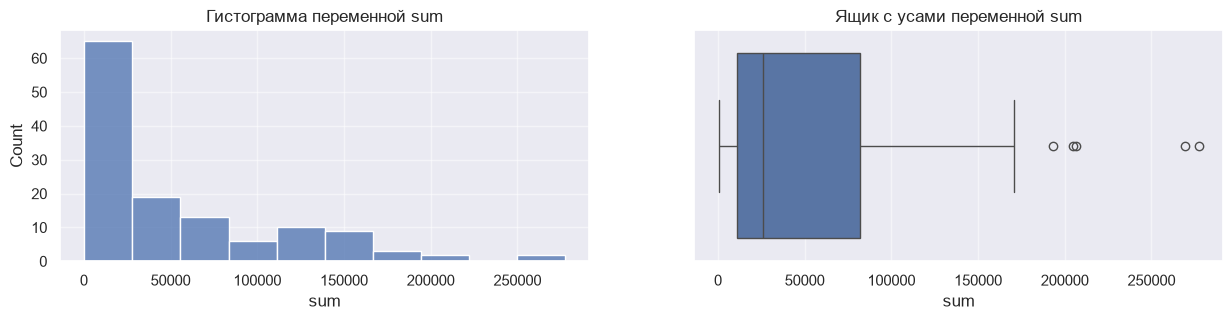

In [20]:
visualize_distribution(dataMonitor, variable="sum")
# 1. Подготовка данных

## 1. Подготовка данных

In [28]:
# Убираем выбросы по правилу +/- 2 стандартных отклонения, z-score
numeric_cols = ['sum', 'is_crysis', 'is_winter', 'is_spring', 'is_summer',
'sum_lag1', 'sum_lag2', 'sum_lag3', 'qty_lag1', 'qty_lag2', 'qty_lag3']
df = dataMonitor[numeric_cols]
df = df[np.abs((dataMonitor['sum']-dataMonitor['sum'].mean())/dataMonitor['sum'].std())<=2]
print(dataMonitor.shape)
print(df.shape)

(129, 19)
(124, 11)


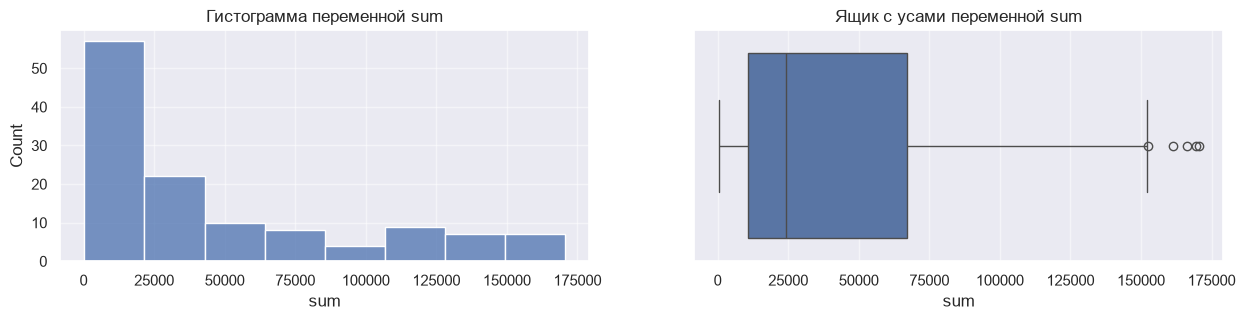

In [22]:
visualize_distribution(df, variable = "sum")

In [23]:
df.head()

,sum,qty,month,is_crysis,is_winter,is_spring,is_summer,sum_lag1,sum_lag2,sum_lag3,qty_lag1,qty_lag2,qty_lag3
0,9016.95,484,1,False,True,False,False,9016.95,9016.95,9016.95,484.0,484.0,484.0
1,9016.95,483,2,False,True,False,False,9016.95,9016.95,9016.95,484.0,484.0,484.0
2,9016.95,487,3,False,False,True,False,9016.95,9016.95,9016.95,483.0,484.0,484.0
3,9016.95,489,4,False,False,True,False,9016.95,9016.95,9016.95,487.0,483.0,484.0
4,9016.95,489,5,False,False,True,False,9016.95,9016.95,9016.95,489.0,487.0,483.0


Sum - Целевая переменная

## 2. Изучаем связь целевой переменной и предикторов

<Figure size 1500x1500 with 0 Axes>

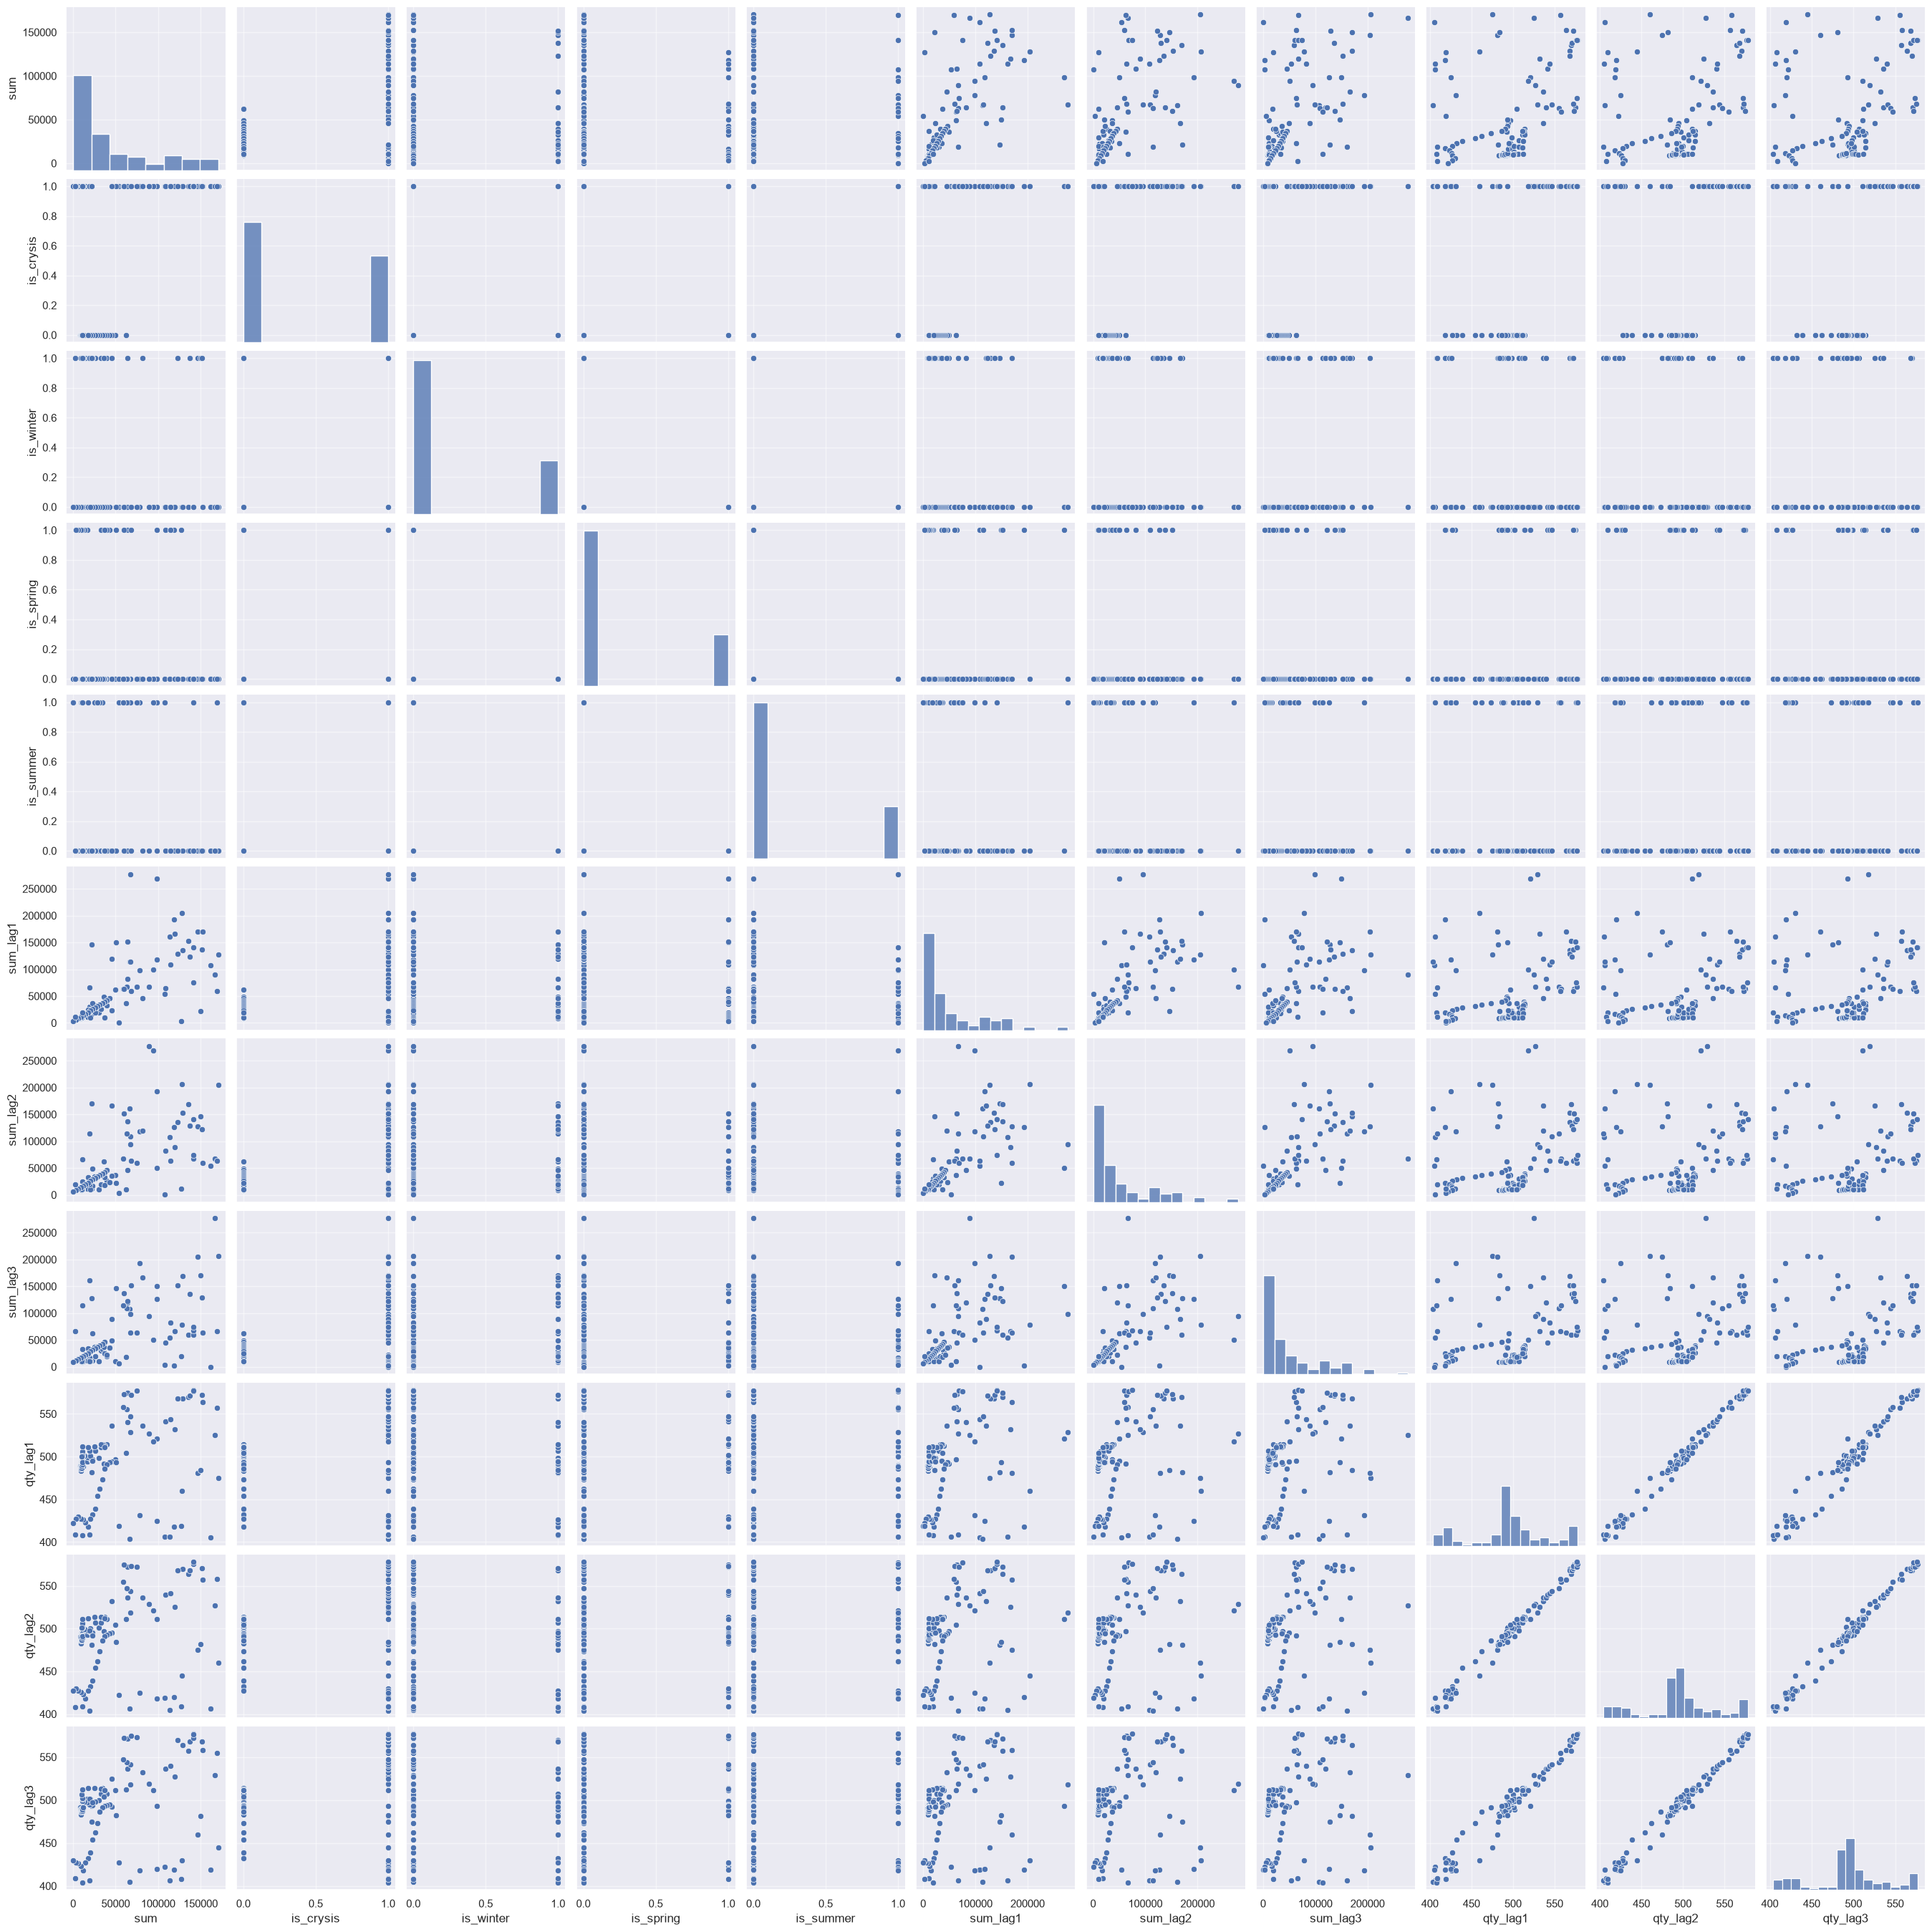

In [29]:
fig = plt.figure(figsize = (15, 15))
sns.pairplot(df)
plt.show()

## 3. Обучим модели линейной регрессии

In [26]:
def split_train_test(df, features_col, target_col):
    X = df[features_col]
    y = df[target_col]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.33, random_state = 42)
    return X_train, X_test, y_train, y_test

def train_model(X_train, y_train):
    model = LinearRegression()
    model.fit(X_train, y_train)
    return model

def get_predictions(model, X_test):
    return model.predict(X_test)

def visualize_prediction(y_true, y_pred):
    fig, ax = plt.subplots(1,1, figsize = (5,5))
    sns.scatterplot(x = y_true.values.ravel(), y = y_pred.ravel(), ax = ax)
    sns.lineplot(x = y_true.values.ravel(), y = y_true.values.ravel(), linestyle = '--', color = 'lightblue', ax = ax)
    ax.set_title("Истинные и предсказанные значения y")
    ax.set_xlabel('true y')
    ax.set_ylabel('pred y')
    plt.show()

def show_metrics(y_true, y_pred):
    print('Среднее значение Y: ', np.mean(y_true))
    print('Среднеквадратическое отклонение Y: ', np.std(y_test, axis = 0).values[0])
    print('MSE: ', mean_squared_error(y_true, y_pred)),
    print('RMSE: ', root_mean_squared_error(y_true, y_pred))
    print('MAE: ', mean_absolute_error(y_true, y_pred))
    print('MAPE: ', mean_absolute_percentage_error(y_true, y_pred))
    print('R2: ', r2_score(y_true, y_pred))

#### Простая модель

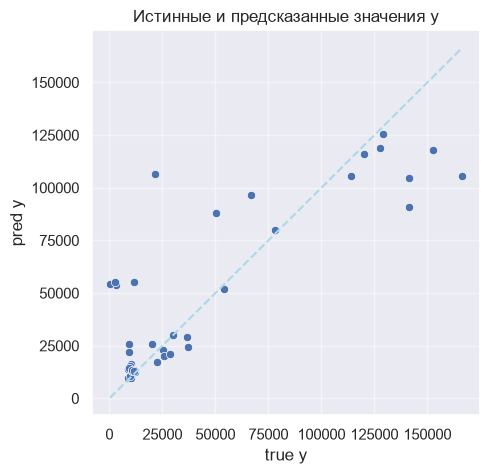

Среднее значение Y:  43167.41062833914
Среднеквадратическое отклонение Y:  49309.910042538744
MSE:  722869828.5732356
RMSE:  26886.2386468103
MAE:  16533.02512050445
MAPE:  5.712562261703403
R2:  0.7027022120105062


In [40]:
target_col = ['sum']
features_col = ['is_crysis', 'is_winter', 'is_spring', 'is_summer',
'sum_lag1', 'sum_lag2', 'sum_lag3', 'qty_lag1', 'qty_lag2', 'qty_lag3']
X_train, X_test, y_train, y_test = split_train_test(df, features_col, target_col)
model = train_model(X_train, y_train)
y_pred = get_predictions(model, X_test)
visualize_prediction(y_test, y_pred)
show_metrics(y_test, y_pred)

## 4. Интерпретируем полученную модель

In [41]:
w0 = model.intercept_   # Забираем intercept
weights = model.coef_   # Забираем веса модели
features = model.feature_names_in_
pd.Series(dict(zip(features.tolist()+['intercept'], weights[0].tolist()+[w0[0]])))

is_crysis    48749.677606
is_winter   -10075.967585
is_spring   -13389.816998
is_summer   -13297.470531
sum_lag1         0.222470
sum_lag2         0.081281
sum_lag3         0.014442
qty_lag1      -591.061750
qty_lag2       638.690821
qty_lag3        69.683445
intercept   -35659.979916
dtype: float64

## $\hat{sum}_i = -35659.979916 + 48749.677606 \cdot is\_crysis_i -10075.967585 \cdot is\_winter_i - 13389.816998 \cdot is\_spring_i - 13297.470531 \cdot is\_summer_i + 0.222470 \cdot sum\_lag1_i + 0.081281 \cdot sum\_lag2_i + 0.014442 \cdot sum\_lag3_i - 597.061750 \cdot qty\_lag1_i + 638.690821 \cdot qty\_lag2_i + 69.683445 \cdot qty\_lag3_i$

In [42]:
def draw_scatteplot(df, x, y, xlab, ylab, y_pred = None):
    data = df.copy()
    plt.figure(figsize = (15,5))
    sns.scatterplot(x = x, y = y, data = data)
    if y_pred is not None:
        data["y_pred"] = y_pred
        sns.lineplot(x = x, y = "y_pred", data = data, c = 'forestgreen')
    plt.xlabel(xlab)
    plt.ylabel(ylab)
    plt.show()

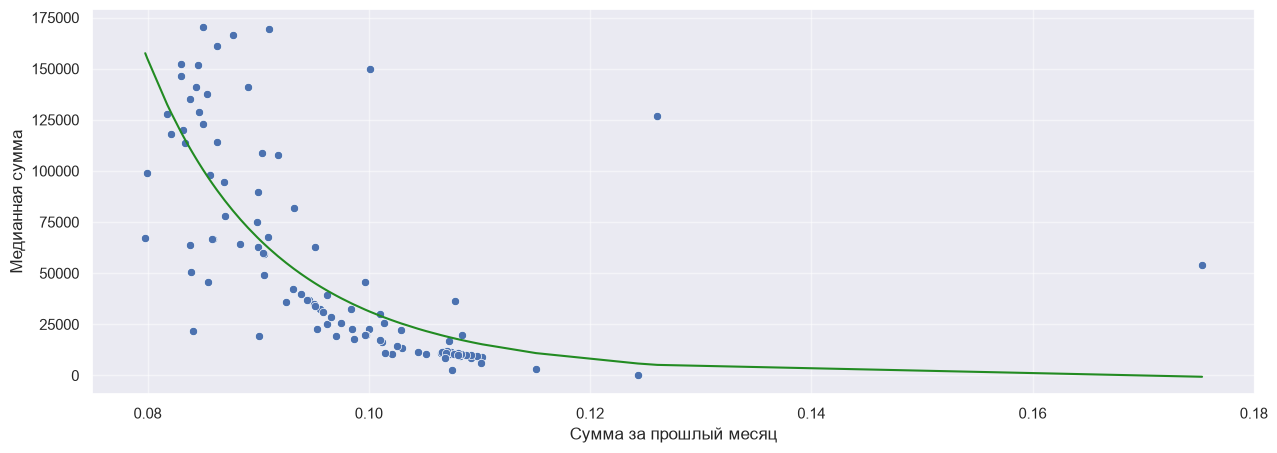

In [59]:
df["sum_lag1_"] = df["sum_lag1"]**(-7) # Трансформируем переменную
target_col = ['sum']
features_col = ['sum_lag1_']
model = train_model(df[features_col], df[target_col])
y_pred = get_predictions(model, df[features_col])
draw_scatteplot(df, x = "sum_lag1", y = "sum", xlab = "Сумма за прошлый месяц", ylab = "Медианная сумма", y_pred = y_pred)

In [ ]:
#df["qty6"] = df["qty"]**6 # Трансформируем переменную
target_col = ['sum']
features_col = ['sum_avg12']
model = train_model(df[features_col], df[target_col])
y_pred = get_predictions(model, df[features_col])
draw_scatteplot(df, x = "sum_avg12", y = "sum", xlab = "Средняя за последний год", ylab = "Медианная сумма", y_pred = y_pred)

In [ ]:
df["avg_price3"] = df["avg_price"]**3 # Трансформируем переменную
target_col = ['sum']
features_col = ['avg_price3']
model = train_model(df[features_col], df[target_col])
y_pred = get_predictions(model, df[features_col])
draw_scatteplot(df, x = "avg_price", y = "sum", xlab = "Средняя цена", ylab = "Медианная сумма", y_pred = y_pred)

In [ ]:
target_col = ['sum']
features_col = ['sum_delta_avg12']
model = train_model(df[features_col], df[target_col])
y_pred = get_predictions(model, df[features_col])
draw_scatteplot(df, x = "sum_delta_avg12", y = "sum", xlab = "Отклонение средней за год", ylab = "Медианная сумма", y_pred = y_pred)

In [ ]:
target_col = ['sum']
features_col = ['delta']
model = train_model(df[features_col], df[target_col])
y_pred = get_predictions(model, df[features_col])
draw_scatteplot(df, x = "delta", y = "sum", xlab = "Отклонение количества сотрудников", ylab = "Медианная сумма", y_pred = y_pred)

## 7. Еще одна версия модели

In [ ]:
target_col = ['sum']
features_col = ['sum', 'qty', 'sum_avg12', 'avg_price', 'sum_delta_avg12', 'delta']
X_train, X_test, y_train, y_test = split_train_test(df, features_col, target_col)
model = train_model(X_train, y_train)
y_pred = get_predictions(model, X_test)
visualize_prediction(y_test, y_pred)
show_metrics(y_test, y_pred)

## 8. Проверим устойчивость модели на разных выборках

In [ ]:
metrics_df = pd.DataFrame()
coefs_df = pd.DataFrame()

target_col = ['sum']
features_col = ['sum', 'qty', 'sum_avg12', 'avg_price', 'sum_delta_avg12', 'delta']

for random_state in range(0, 20, 2):
  X_train, X_test, y_train, y_test = train_test_split(df[features_col], df[target_col], test_size = 0.33, random_state = random_state)

  reg = LinearRegression()
  reg.fit(X_train, y_train)
  y_pred = reg.predict(X_test)

  df1 = pd.DataFrame(
      {
          'MSE'  : mean_squared_error(y_test, y_pred),
          'RMSE' : root_mean_squared_error(y_test, y_pred),
          'MAE'  : mean_absolute_error(y_test, y_pred),
          'MAPE' : mean_absolute_percentage_error(y_test, y_pred),
          'R2'   : r2_score(y_test, y_pred)
      },
      index = [random_state]
  )

  df2 = pd.DataFrame(
      index = X_train.columns,
      data = reg.coef_[0],
      columns = [random_state]
  )

  metrics_df = pd.concat([metrics_df, df1])
  coefs_df = pd.concat([coefs_df, df2], axis = 1)

In [ ]:
metrics_df

In [ ]:
coefs_df.T

## 9. Variance inflation factor

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

target_col = ['sum']
features_col = ['sum', 'qty', 'sum_avg12', 'avg_price', 'sum_delta_avg12', 'delta']

#X = df[features_col]
#y = df[target_col]
X = dataMonitor[features_col]
y = dataMonitor[target_col]

vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]
vif_data.sort_values(by = 'VIF', ascending = False).reset_index(drop = True)